In [9]:
# Run this cell if using a colab remote kernel and unable to resolve the import `from layoffs.data_loader import load_data`
# uncomment the first line if you have not run on this kernel before
# !git clone https://github.com/sidharthmirch/layoffs.git
!git -C /content/layoffs pull
import sys; sys.path.insert(0, '/content/layoffs')

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.65 KiB | 71.00 KiB/s, done.
From https://github.com/sidharthmirch/layoffs
   43deef5..e6d9726  main       -> origin/main
Updating 43deef5..e6d9726
Fast-forward
 classifier.ipynb | 383 ++++++++++++++++++++++++++++++++++++++++++++++++++++++-
 explorer.ipynb   |  46 ++++++-
 2 files changed, 419 insertions(+), 10 deletions(-)


In [10]:
import pandas as pd
from layoffs.data_loader import load_data

train_df, test_df = load_data()

train_df.head()

Using Colab cache for faster access to the 'global-company-layoffs-prediction-dataset' dataset.


,company,industry,country,funding_amount,employee_count,growth_rate,valuation,layoff_happened
0,Company_vrzD7Zhl,Real Estate,USA,917215428,53060,143.37,1.706021e+09,0
1,Company_3OJQGaHb,Automotive,Germany,3886088690,98556,177.24,1.869209e+10,0
2,Company_iChfXlEW,Real Estate,Germany,509868992,65992,58.26,3.079609e+09,1
3,Company_GBHyTQ2d,Logistics,UK,4180168950,38180,111.39,2.173688e+10,0
4,Company_cpOLkT6x,Tech,Japan,3031189942,56530,174.79,2.667447e+10,1


## Preprocessing pipeline

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

target_col = "layoff_happened"

X_train = train_df.drop(columns=[target_col]).copy()
y_train = train_df[target_col].copy()

X_test = test_df.drop(columns=[target_col]).copy()
y_test = test_df[target_col].copy()

# removing string company name as no predictive value
# based on eda potential set with only growth rate as predictor?
drop_cols = ["company"] 
X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")

# categorical encoding
categorical_cols = ["country", "industry"] 
for c in categorical_cols:
    if c in X_train.columns:
        X_train[c] = X_train[c].astype("category")
        X_test[c] = X_test[c].astype("category")


numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),],
    remainder="drop")

In [12]:
feature_col = ["growth_rate"]
# building growth_rate only sets

X_train_gr = train_df[feature_col].copy()
y_train_gr = train_df[target_col].copy()

X_test_gr = test_df[feature_col].copy()
y_test_gr = test_df[target_col].copy()

numeric_cols_gr = ["growth_rate"]
categorical_cols_gr = []

numeric_pipe_gr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_gr = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe_gr, numeric_cols_gr)
    ],
    remainder="drop"
)

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_validate, StratifiedKFold

dummy_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=123))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

dummy_scores = cross_validate(
    dummy_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"])

print("Dummy CV accuracy:", dummy_scores["test_accuracy"].mean())
print("Dummy CV f1:", dummy_scores["test_f1"].mean())
print("Dummy CV roc_auc:", dummy_scores["test_roc_auc"].mean())

Dummy CV accuracy: 0.6838749999999999
Dummy CV f1: 0.0
Dummy CV roc_auc: 0.5


In [14]:
from plotnine import ggplot, aes, geom_line, geom_point, geom_ribbon, geom_hline, labs, theme_bw, annotate
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=10,
        random_state=123,
        class_weight="balanced",
        n_jobs=-1
    ))])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

rf_scores = cross_validate(
    rf_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False)

print("RF CV accuracy:", rf_scores["test_accuracy"].mean())
print("RF CV f1:", rf_scores["test_f1"].mean())
print("RF CV roc_auc:", rf_scores["test_roc_auc"].mean())

RF CV accuracy: 0.687125
RF CV f1: 0.33984148618451626
RF CV roc_auc: 0.6210326527585865


## Hyperparameter optimization — n_estimators

In [15]:
# first run was: [10, 25, 50, 100, 150, 200, 300, 500]
# best n was 150
# next run was [50, 75, 100, 125, 150, 175, 200]
# nice range of accuracy and std dev in 100---200
# still, we peak at 150 
n_estimator_values = [120, 130, 140, 150, 160, 170, 180]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

results = []
for n in n_estimator_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=123, class_weight="balanced", n_jobs=-1)
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", rf)])
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    results.append({
        "n_estimators": n,
        "mean_accuracy": cv_results["test_score"].mean(),
        "std_accuracy": cv_results["test_score"].std(),
    })

results_df = pd.DataFrame(results)
best_n = results_df.loc[results_df["mean_accuracy"].idxmax(), "n_estimators"]
print(f"Best n_estimators: {best_n}")
results_df

Best n_estimators: 150


,n_estimators,mean_accuracy,std_accuracy
0,120,0.702625,0.005483
1,130,0.701875,0.005303
2,140,0.702250,0.006042
3,150,0.702625,0.004565
4,160,0.702500,0.004330
5,170,0.702250,0.004465
6,180,0.701625,0.004737


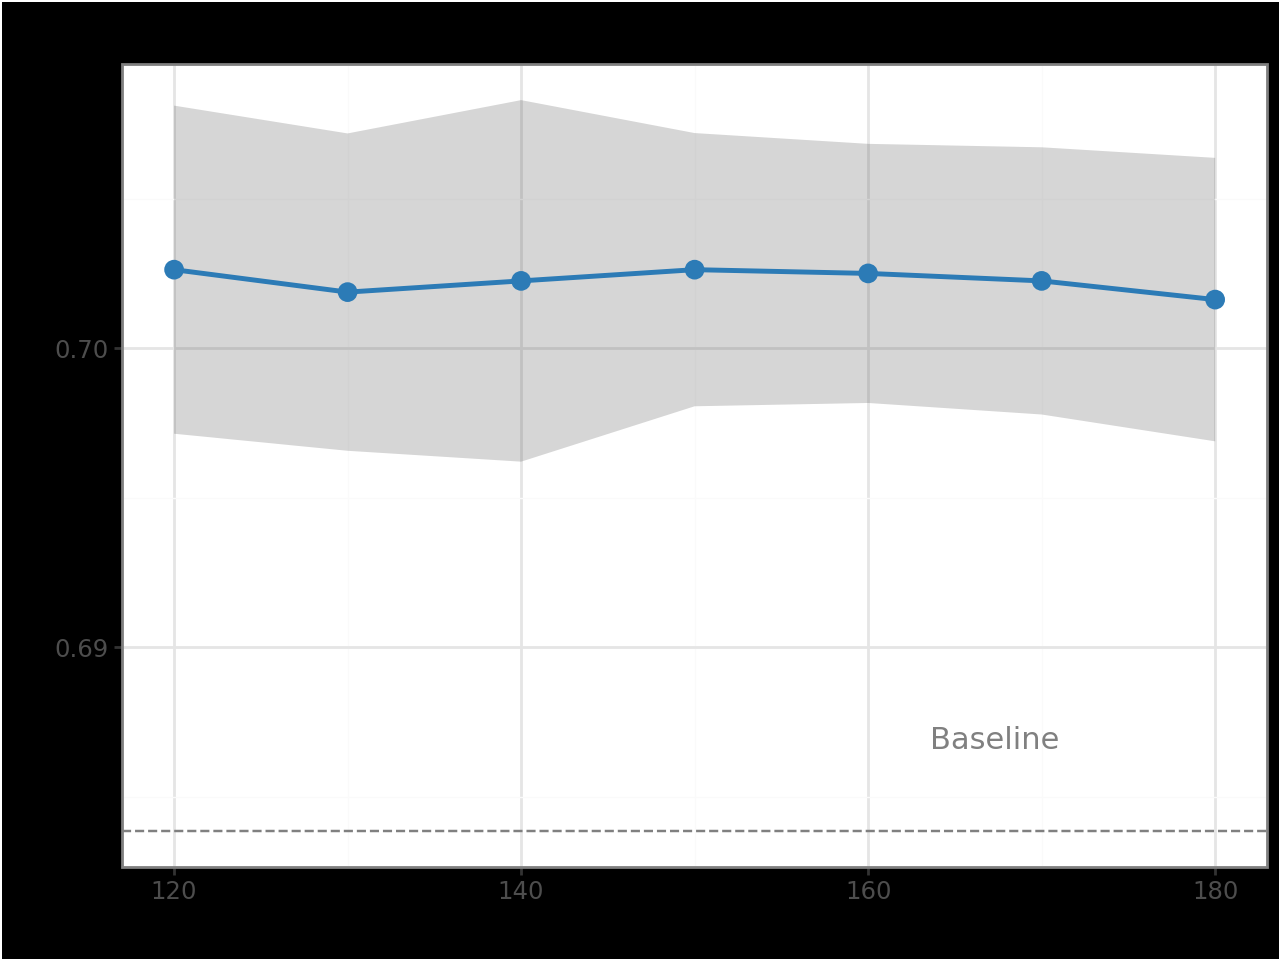

In [16]:
baseline_acc = dummy_scores["test_accuracy"].mean()

(
    ggplot(results_df, aes(x="n_estimators", y="mean_accuracy"))
    + geom_ribbon(aes(ymin="mean_accuracy - std_accuracy", ymax="mean_accuracy + std_accuracy"), alpha=0.2)
    + geom_line(color="#2c7bb6", size=1)
    + geom_point(color="#2c7bb6", size=3)
    + geom_hline(yintercept=baseline_acc, linetype="dashed", color="gray")
    + annotate("text", x=max(n_estimator_values) * 0.95, y=baseline_acc + 0.003, label="Baseline", color="gray", ha="right")
    + labs(title="RF Accuracy vs n_estimators", x="n_estimators", y="Mean CV Accuracy (5-fold)")
    + theme_bw()
)

## Modelling only `growth_rate` as a feature

In [17]:
rf_pipeline_gr = Pipeline(steps=[
    ("prep", preprocessor_gr),
    ("model", RandomForestClassifier(
        n_estimators=10,
        random_state=123,
        class_weight="balanced",
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

rf_scores_gr = cross_validate(
    rf_pipeline_gr,
    X_train_gr, y_train_gr,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

print("RF (growth_rate only) CV accuracy:", rf_scores_gr["test_accuracy"].mean())
print("RF (growth_rate only) CV f1:", rf_scores_gr["test_f1"].mean())
print("RF (growth_rate only) CV roc_auc:", rf_scores_gr["test_roc_auc"].mean())

RF (growth_rate only) CV accuracy: 0.6252500000000001
RF (growth_rate only) CV f1: 0.38684778510568174
RF (growth_rate only) CV roc_auc: 0.5793535194288233


In [18]:
from sklearn.linear_model import LogisticRegression

lr_pipeline_gr = Pipeline(steps=[
    ("prep", preprocessor_gr),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=123
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

lr_scores_gr = cross_validate(
    lr_pipeline_gr,
    X_train_gr, y_train_gr,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

print("LR (growth_rate only) CV accuracy:", lr_scores_gr["test_accuracy"].mean())
print("LR (growth_rate only) CV f1:", lr_scores_gr["test_f1"].mean())
print("LR (growth_rate only) CV roc_auc:", lr_scores_gr["test_roc_auc"].mean())

LR (growth_rate only) CV accuracy: 0.578125
LR (growth_rate only) CV f1: 0.46922133794852705
LR (growth_rate only) CV roc_auc: 0.6284089265598884


In [19]:
from sklearn.metrics import make_scorer, precision_score, recall_score, average_precision_score, matthews_corrcoef

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "mcc": make_scorer(matthews_corrcoef)
}

lr_scores_gr = cross_validate(
    lr_pipeline_gr,
    X_train_gr, y_train_gr,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Printing the most relevant imbalanced metrics
print("LR Balanced Accuracy:", lr_scores_gr["test_balanced_accuracy"].mean())
print("LR Precision (Minority):", lr_scores_gr["test_precision"].mean())
print("LR Recall (Minority):", lr_scores_gr["test_recall"].mean())
print("LR PR AUC (Avg Precision):", lr_scores_gr["test_pr_auc"].mean())
print("LR Matthews Corr Coef:", lr_scores_gr["test_mcc"].mean())

LR Balanced Accuracy: 0.5813082883723389
LR Precision (Minority): 0.3895889239565425
LR Recall (Minority): 0.5899589089343716
LR PR AUC (Avg Precision): 0.45686554222718945
LR Matthews Corr Coef: 0.15139413968314083


## Model Comparison & Feature Analysis

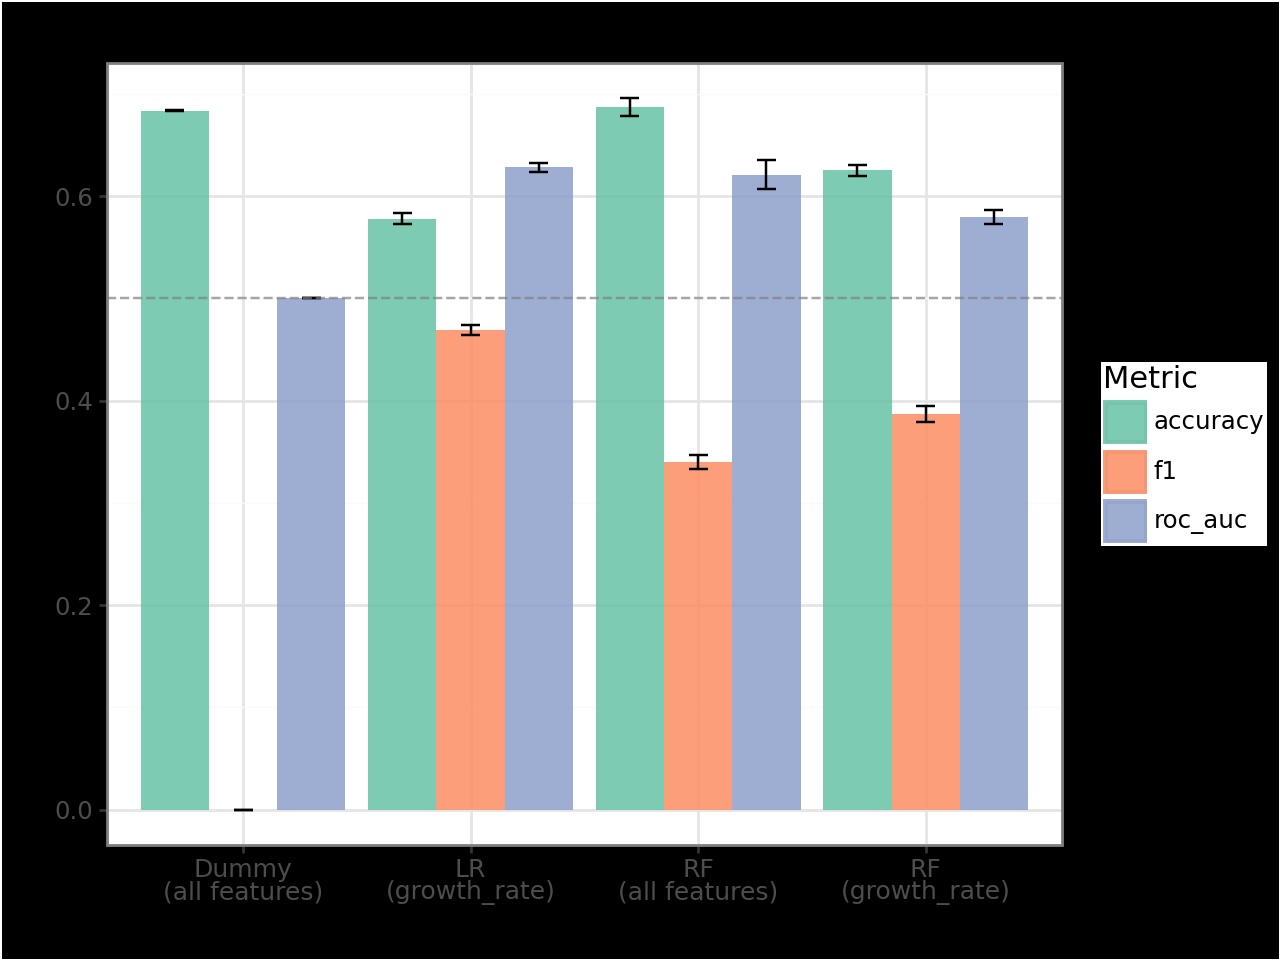

In [20]:
from plotnine import (
    ggplot, aes, geom_bar, geom_errorbar, geom_hline,
    labs, theme_bw, theme, element_text, scale_fill_brewer,
    position_dodge
)
import numpy as np

# Collect CV metrics across all four models
model_metrics = []
for model_name, scores in [
    ("Dummy\n(all features)", dummy_scores),
    ("RF\n(all features)", rf_scores),
    ("RF\n(growth_rate)", rf_scores_gr),
    ("LR\n(growth_rate)", lr_scores_gr),
]:
    for metric in ["accuracy", "f1", "roc_auc"]:
        vals = scores[f"test_{metric}"]
        model_metrics.append({
            "model": model_name,
            "metric": metric,
            "mean": vals.mean(),
            "ymin": max(0.0, vals.mean() - vals.std()),
            "ymax": vals.mean() + vals.std(),
        })

metrics_df = pd.DataFrame(model_metrics)

dodge = position_dodge(width=0.9)

(
    ggplot(metrics_df, aes(x="model", y="mean", fill="metric"))
    + geom_bar(stat="identity", position=dodge, alpha=0.85)
    + geom_errorbar(aes(ymin="ymin", ymax="ymax"), position=dodge, width=0.25)
    + geom_hline(yintercept=0.5, linetype="dashed", color="gray", alpha=0.7)
    + scale_fill_brewer(type="qual", palette="Set2")
    + labs(
        title="Model Comparison: CV Metrics (mean ± 1 std, 5-fold)",
        x="Model", y="Mean CV Score", fill="Metric"
    )
    + theme_bw()
    + theme(axis_text_x=element_text(size=9))
)

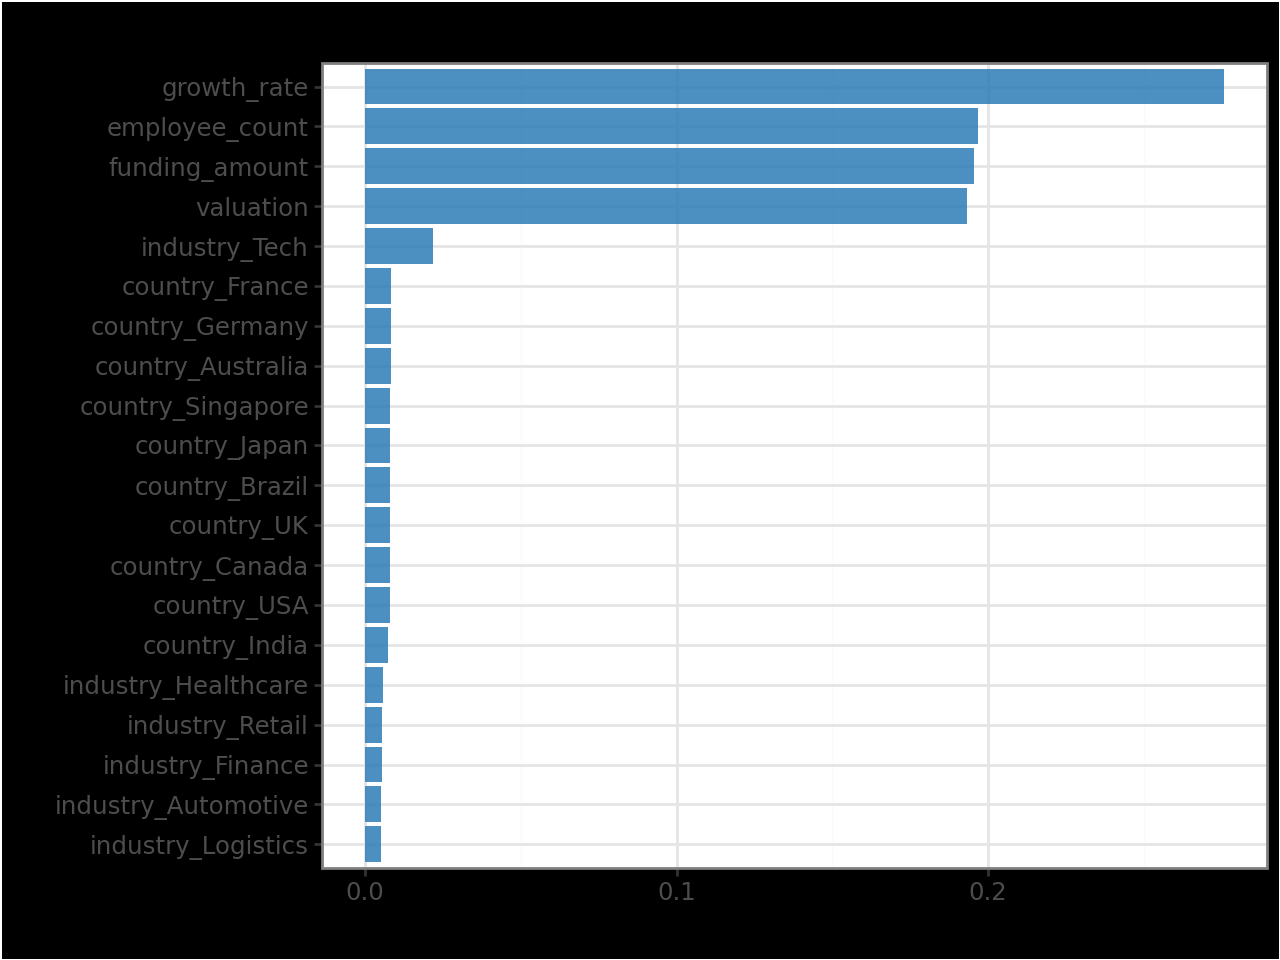

In [21]:
from plotnine import coord_flip, annotate

# Fit RF with optimal n_estimators=150 on the full training set for inspection
rf_full = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=150, random_state=123, class_weight="balanced", n_jobs=-1))
])
rf_full.fit(X_train, y_train)

# Get feature names from the fitted ColumnTransformer
feature_names = rf_full.named_steps["prep"].get_feature_names_out()
importances = rf_full.named_steps["model"].feature_importances_

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)
# Strip sklearn prefixes (num__, cat__)
fi_df["feature"] = fi_df["feature"].str.replace(r"^(num__|cat__)", "", regex=True)

(
    ggplot(fi_df, aes(x="reorder(feature, importance)", y="importance"))
    + geom_bar(stat="identity", fill="#2c7bb6", alpha=0.85)
    + coord_flip()
    + labs(
        title="RF Feature Importances — all features (top 20)",
        x="Feature", y="Mean Decrease in Impurity"
    )
    + theme_bw()
)

RF (growth_rate only) — feature importance: 1.0000  (trivially 1.0 with single feature)
LR (growth_rate only) — coefficient: -0.4376, intercept: -0.0363

Positive LR coefficient → higher growth_rate increases predicted probability of layoff.


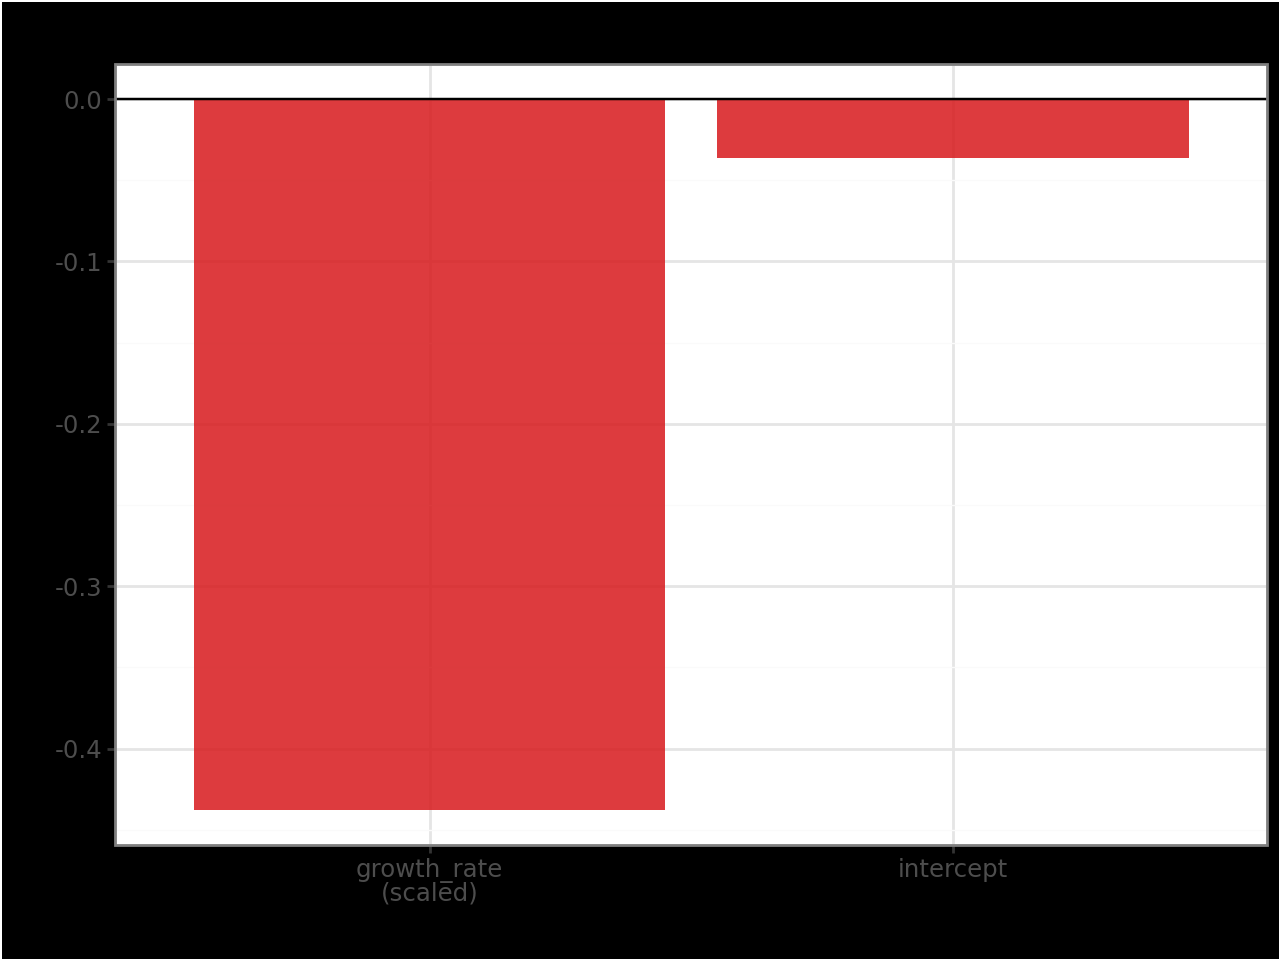

In [22]:
from plotnine import scale_fill_manual

# Refit both single-feature models on full training data for coefficient/importance inspection
rf_pipeline_gr.fit(X_train_gr, y_train_gr)
lr_pipeline_gr.fit(X_train_gr, y_train_gr)

lr_coef = lr_pipeline_gr.named_steps["model"].coef_[0][0]
lr_intercept = lr_pipeline_gr.named_steps["model"].intercept_[0]

rf_gr_importance = rf_pipeline_gr.named_steps["model"].feature_importances_[0]

print(f"RF (growth_rate only) — feature importance: {rf_gr_importance:.4f}  (trivially 1.0 with single feature)")
print(f"LR (growth_rate only) — coefficient: {lr_coef:.4f}, intercept: {lr_intercept:.4f}")
print(f"\nPositive LR coefficient → higher growth_rate increases predicted probability of layoff.")

coef_df = pd.DataFrame({
    "term": ["growth_rate\n(scaled)", "intercept"],
    "value": [lr_coef, lr_intercept],
    "positive": [lr_coef > 0, lr_intercept > 0],
})

(
    ggplot(coef_df, aes(x="term", y="value", fill="positive"))
    + geom_bar(stat="identity", alpha=0.85, show_legend=False)
    + geom_hline(yintercept=0, color="black", size=0.5)
    + scale_fill_manual(values={True: "#2c7bb6", False: "#d7191c"})
    + labs(
        title="Logistic Regression Coefficients (growth_rate model, standardized input)",
        x="Term", y="Coefficient Value"
    )
    + theme_bw()
)